# 01 — Veri Şeması ve Genel Özet

Bu notebook sentetik wetstock veri ambarının **ilk tanışma** adımıdır.

**Kapsam:**
- 8 operasyonel tablonun yüklenmesi
- Satır/kolon/null özeti
- İstasyon ve tank dağılımı
- Tarih aralığı ve granülarite

> `ground_truth/` klasörünü bu aşamada **kullanmıyoruz** — anomalileri kendimiz keşfedeceğiz.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all, summary_table, DATA_DIR
from utils.plots import setup_style

setup_style()
sns.set_theme(style='whitegrid')
print('Veri klasörü:', DATA_DIR)
dfs = load_all()
list(dfs.keys())

Veri klasörü: /Users/mangtay/Desktop/Staj/data


['stations',
 'tanks',
 'mapping',
 'transactions',
 'deliveries',
 'inventory_30min',
 'ue1t_30min',
 'daily']

In [2]:
# Tablo özeti
ozet = summary_table(dfs)
display(ozet)

,tablo,satir,kolon,null_kolon_sayisi,toplam_null,null_detay
0,stations,8,3,0,0,{}
1,tanks,32,11,0,0,{}
2,mapping,81,7,1,2,{'manifold_grup_no': 2}
3,transactions,231874,11,3,3938,"{'tank_no': 2548, 'litre': 463, 'birim_fiyat':..."
4,deliveries,1109,12,3,367,"{'dolum_oncesi_hacim': 88, 'sicaklik': 109, 'm..."
5,inventory_30min,138194,11,5,852,"{'urun_miktari_net': 240, 'su_seviyesi_cm': 48..."
6,ue1t_30min,138194,16,2,654,"{'sicaklik': 240, 'baslangic_seviyesi_cm': 414}"
7,daily,2880,13,0,0,{}


In [3]:
# Her tablonun kolonları
for name, df in dfs.items():
    print('=' * 60)
    print(f'{name}: {df.shape[0]:,} satır x {df.shape[1]} kolon')
    print('Kolonlar:', list(df.columns))
    print(df.dtypes)
    print()

stations: 8 satır x 3 kolon
Kolonlar: ['istasyon_kodu', 'bolge', 'tank_sayisi']
istasyon_kodu    object
bolge            object
tank_sayisi       int64
dtype: object

tanks: 32 satır x 11 kolon
Kolonlar: ['istasyon_kodu', 'tank_no', 'urun_no', 'akaryakit_turu', 'kapasite', 'tank_capi', 'tank_uzunlugu', 'bolmeli', 'bolme_grup_no', 'is_manifold', 'manifold_grup_no']
istasyon_kodu       object
tank_no              int64
urun_no              int64
akaryakit_turu      object
kapasite             int64
tank_capi            int64
tank_uzunlugu        int64
bolmeli              int64
bolme_grup_no        int64
is_manifold          int64
manifold_grup_no     int64
dtype: object

mapping: 81 satır x 7 kolon
Kolonlar: ['istasyon_kodu', 'pompa_no', 'tabanca_no', 'tank_no', 'urun_no', 'akaryakit_turu', 'manifold_grup_no']
istasyon_kodu        object
pompa_no              int64
tabanca_no            int64
tank_no               int64
urun_no               int64
akaryakit_turu       object
manifold_gr

In [4]:
# İstasyon × tank matrisi
stations = dfs['stations']
tanks = dfs['tanks']
print(stations.to_string(index=False))
print()
print('Tank sayısı istasyon başına:')
print(tanks.groupby('istasyon_kodu').size().to_string())

istasyon_kodu        bolge  tank_sayisi
      IST_001      Marmara            5
      IST_002          Ege            5
      IST_003      Marmara            3
      IST_004   Ic Anadolu            5
      IST_005   Ic Anadolu            3
      IST_006      Akdeniz            4
      IST_007    Karadeniz            4
      IST_008 Dogu Anadolu            3

Tank sayısı istasyon başına:
istasyon_kodu
IST_001    5
IST_002    5
IST_003    3
IST_004    5
IST_005    3
IST_006    4
IST_007    4
IST_008    3


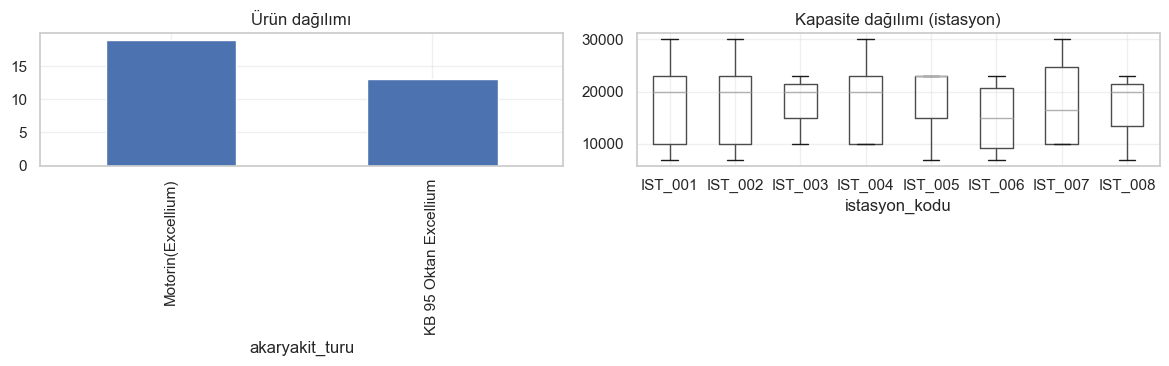

In [5]:
# Ürün ve kapasite dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tanks['akaryakit_turu'].value_counts().plot(kind='bar', ax=axes[0], title='Ürün dağılımı')
tanks.boxplot(column='kapasite', by='istasyon_kodu', ax=axes[1])
axes[1].set_title('Kapasite dağılımı (istasyon)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [6]:
# Tarih aralığı
daily = dfs['daily']
tx = dfs['transactions']
print('Daily  :', daily.tarih.min(), '→', daily.tarih.max(), f'({daily.tarih.nunique()} gün)')
print('TX     :', tx.satis_zamani.min(), '→', tx.satis_zamani.max())
print('Beklenen daily satır (32 tank × 90 gün):', 32 * 90)
print('Gerçek daily satır:', len(daily))

Daily  : 2026-01-01 00:00:00 → 2026-03-31 00:00:00 (90 gün)
TX     : 2026-01-01 00:01:19 → 2026-03-31 23:59:31
Beklenen daily satır (32 tank × 90 gün): 2880
Gerçek daily satır: 2880


In [7]:
# Granülarite tablosu
gran = pd.DataFrame([
    ['transactions', 'tekil satış', 'değişken (~100+/gün/tank)'],
    ['ue1t_30min', '30 dakika', '48/gün/tank'],
    ['inventory_30min', '30 dakika', '48/gün/tank'],
    ['daily', 'günlük', '1/gün/tank'],
    ['deliveries', 'olay bazlı', 'dolum olduğunda'],
], columns=['tablo', 'granülarite', 'beklenen'])
display(gran)

,tablo,granülarite,beklenen
0,transactions,tekil satış,değişken (~100+/gün/tank)
1,ue1t_30min,30 dakika,48/gün/tank
2,inventory_30min,30 dakika,48/gün/tank
3,daily,günlük,1/gün/tank
4,deliveries,olay bazlı,dolum olduğunda


## Sonuç

- Veri **yıldız şeması**: `istasyon_kodu + tank_no` ile tüm tablolar birbirine bağlanır.
- Sonraki notebook: katman tutarlılığı doğrulaması (`02_katman_tutarliligi.ipynb`).